In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("Hey!!")
result

d:\agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hey there! 😊 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hey!!". The system instructions: we should respond with a friendly greeting. We should keep it brief. The user hasn\'t asked a question yet. So we can respond with a greeting.'}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 73, 'total_tokens': 135, 'completion_time': 0.062778851, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.003502277, 'prompt_tokens_details': None, 'queue_time': 0.314274868, 'total_time': 0.066281128}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fad51-d7e0-7af3-a4ee-f04d76f5e095-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 62, 'total_tokens': 135, 'output_token_details': {'reasoning': 42}})

In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [8]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

d:\agenticai\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\prana\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6598.14it/s]


In [5]:
urls=[
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceCheckpointersStoresFault toleranceEvent streamingStreamingInterruptsTim

In [7]:
doc_list = [doc for sublist in docs for doc in sublist]
print(doc_list)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits = text_splitter.split_documents(doc_list)
print(doc_splits[:2])

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceCheckpointersStoresFault toleranceEvent streamingStreamingInterruptsTime

In [10]:
vectorStore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
)

retreiver = vectorStore.as_retriever()

In [11]:
retreiver.invoke("What is Langgraph?")

[Document(id='76afde95-6444-4c57-be39-44f5bb9def6d', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bAcknowledgements\nLangGraph is inspired by Pregel and Apache Beam. The public interface draws inspiration from NetworkX. LangGraph is built by LangChain Inc, the creators of LangChain, but can be used without LangChain.'),
 Document(id='fe964fff-ac31-4d15-8884-90aa8015bdf9', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph is very low-level, and focused entirely on agent orchestration. Before using LangGraph, we recommend you familiarize yourself with 

In [12]:
from langchain_core.tools.retriever import create_retriever_tool
retriever_tool=create_retriever_tool(
    retreiver,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

In [13]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001D7BFF07100>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001D7BFF072E0>)

In [14]:
lc_url = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/deepagents/rag",   
]

docs = [WebBaseLoader(url).load() for url in lc_url]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-t

In [15]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

vectorstorelangchain=FAISS.from_documents(
    documents=doc_splits,
    embedding= embeddings
)

retrieverlc=vectorstorelangchain.as_retriever()

In [16]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverlc,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [17]:
tools = [retriever_tool, retriever_tool_langchain]

In [18]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [19]:
def agent(state):
    """
        Invokes the agent model to generate a response based on the current state. Given
        the question, it will decide to retrieve using the retriever tool, or simply end.
    
        Args:
            state (messages): The current state
    
        Returns:
            dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = llm.bind_tools(tools)
    response = model.invoke(messages)
    return {"messages": [response]}

In [28]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field

from langsmith import Client
client = Client(api_key=os.getenv("LANGSMITH_API_KEY"))
prompt = client.pull_prompt("rlm/rag-prompt", include_model=True,dangerously_pull_public_prompt=True)

In [30]:
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")


    llm_with_tool = llm.with_structured_output(grade)

    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [31]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    prompt = client.pull("rlm/rag-prompt")

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | llm | StrOutputParser()

    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [32]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    response = llm.invoke(msg)
    return {"messages": [response]}

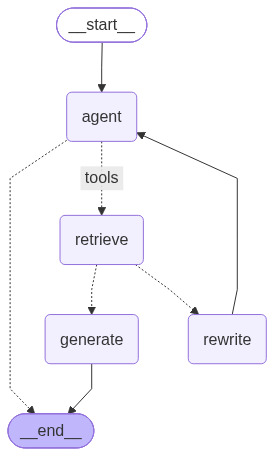

In [33]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve) 
workflow.add_node("rewrite", rewrite) 
workflow.add_node(
    "generate", generate
)
workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)

workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [34]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='a1eadead-8e55-4825-9ffd-b9eedf9a9f6e'),
  AIMessage(content='## Langgraph – The “Graph‑Based” LLM App Framework\n\n| Feature | What It Is | Why It Matters |\n|---------|------------|----------------|\n| **Graph of LLM calls** | A directed graph where each **node** is an LLM prompt, function call, or external API, and each **edge** represents a possible transition. | Lets you model complex, multi‑step workflows (e.g., a chatbot that searches a database, refines a query, and returns an answer) without writing a lot of boilerplate code. |\n| **Stateful, typed state** | A typed `state` object flows through the graph. Each node can read, modify, and return the state. | Guarantees that every part of the workflow has consistent, type‑checked access to the data it needs. |\n| **Built on LangChain** | Re‑uses LangChain’s tools, memory, embeddings, etc. | You can drop in any LangChain compone

In [35]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='1d10aaf4-63d4-47a2-ad56-41ff473e91ec'),
  AIMessage(content='**LangChain** is an open‑source framework designed to simplify the creation of applications that use large language models (LLMs). It abstracts many of the repetitive, boilerplate tasks that developers face when building LLM‑powered systems, letting you focus on the *logic* of your application rather than the plumbing.\n\n---\n\n## 1. Core Idea\n\n- **Composable building blocks** – Think of LangChain as a set of reusable “components” (prompts, models, memory, tools, etc.) that you can string together into a pipeline (a “chain”).\n- **LLM‑agnostic** – It supports dozens of LLM providers (OpenAI, Anthropic, Cohere, Azure, Hugging Face, etc.) and can swap them out with minimal code changes.\n- **Extensible** – You can plug in custom models, tools, or even build your own components and register them with the framework.\n\n---\

In [36]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='c84029a1-fef7-4481-ae39-efc140680524'),
  AIMessage(content='**Machine Learning (ML)** is a branch of artificial intelligence that focuses on building systems that can learn from data, identify patterns, and make decisions with minimal human intervention. Rather than being explicitly programmed for every task, an ML model learns how to perform a task by analyzing examples and adjusting its internal parameters to improve its performance over time.\n\n---\n\n## Core Ideas\n\n| Concept | What it means | Example |\n|---------|---------------|---------|\n| **Data‑driven** | The system’s knowledge comes from data rather than hard‑coded rules. | A spam filter learns from thousands of emails labeled “spam” or “ham.” |\n| **Model** | A mathematical function that maps inputs to outputs. | A neural network, decision tree, or linear regression model. |\n| **Training** | The process of ad